In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [153]:
#Droping resume html cause it is identical with resume str
data = pd.read_csv(r"D:\Data Science\ML Model\Resume Analyser\Resume.csv").drop(["ID","Resume_html"],axis = 1)

In [154]:
data.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [155]:
data.tail()

,Resume_str,Category
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,GEEK SQUAD AGENT Professional...,AVIATION
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION
2483,STOREKEEPER II Professional Sum...,AVIATION


In [156]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Resume_str  2484 non-null   object
 1   Category    2484 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB


In [157]:
data.describe()

,Resume_str,Category
count,2484,2484
unique,2482,24
top,STOREKEEPER II Professional Sum...,INFORMATION-TECHNOLOGY
freq,2,120


In [158]:
print("Null Values: ",data.isnull().sum())

Null Values:  Resume_str    0
Category      0
dtype: int64


In [159]:
print("Category: ",data["Category"].value_counts())

Category:  Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


Text(0.5, 1.0, 'Category Distribution')

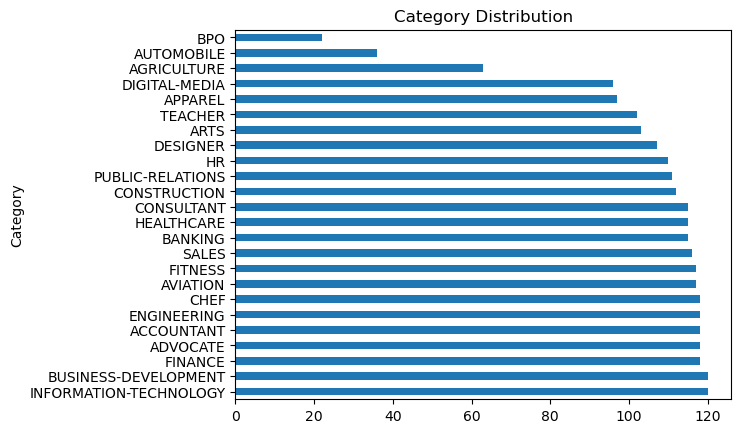

In [160]:
data["Category"].value_counts().plot(
    kind = "barh"
)
plt.title("Category Distribution")

In [161]:
# (data["Resume_html"][0])

In [162]:
# resume = data["Resume_html"].iloc[0]

In [163]:
# def remove_html(text):
#     soup = BeautifulSoup(text,"html.parser")
#     return soup.get_text()

In [164]:
# data.columns

In [165]:
# data["Resume_html"] = data["Resume_html"].apply(remove_html)

In [166]:
# data["Resume_html"]

In [167]:
# print(data["Resume_str"].iloc[0][:1000])

In [168]:
# print(data["Resume_html"].iloc[0][:1000])

In [169]:
data.rename(
    columns={
        "Resume_str": "Resume"
    },
    inplace=True
)

In [170]:
data

,Resume,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,GEEK SQUAD AGENT Professional...,AVIATION
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


In [171]:
print("Data Shape: ",data.shape)

Data Shape:  (2484, 2)


In [172]:
print("Unique Category: ",data["Category"].value_counts())

Unique Category:  Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [173]:
data["Resume_Length"] = data["Resume"].apply(len)

In [174]:
data["Resume_Length"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_Length, dtype: float64

(array([ 53., 310., 843., 805., 289.,  93.,  47.,  18.,   7.,   5.,   6.,
          2.,   3.,   0.,   0.,   1.,   0.,   0.,   1.,   1.]),
 array([2.100000e+01, 1.962050e+03, 3.903100e+03, 5.844150e+03,
        7.785200e+03, 9.726250e+03, 1.166730e+04, 1.360835e+04,
        1.554940e+04, 1.749045e+04, 1.943150e+04, 2.137255e+04,
        2.331360e+04, 2.525465e+04, 2.719570e+04, 2.913675e+04,
        3.107780e+04, 3.301885e+04, 3.495990e+04, 3.690095e+04,
        3.884200e+04]),
 <BarContainer object of 20 artists>)

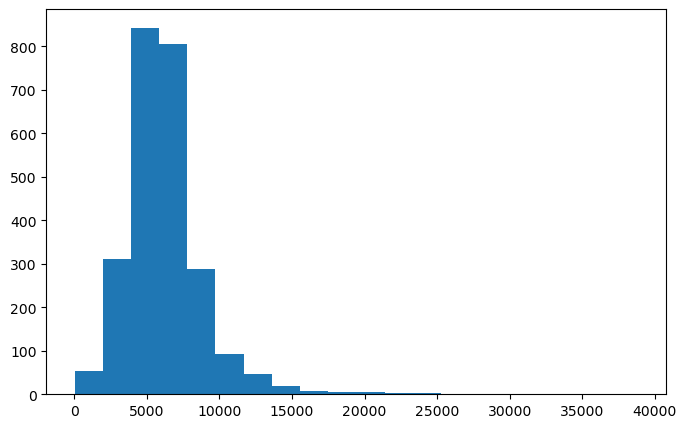

In [175]:
plt.figure(figsize=(8,5))
plt.hist(data["Resume_Length"],bins=20)

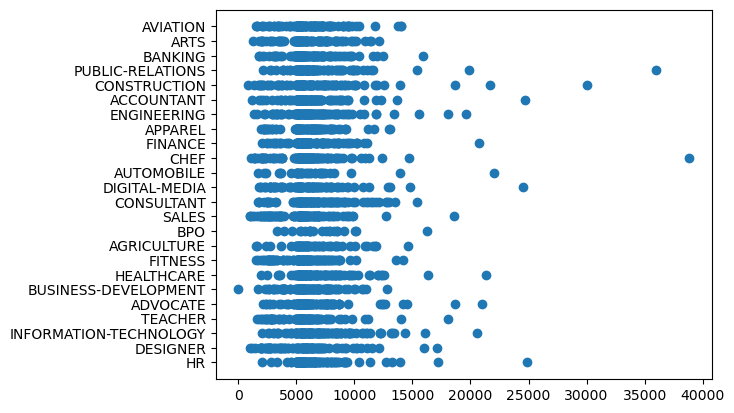

In [176]:
plt.scatter(data["Resume_Length"],data["Category"])

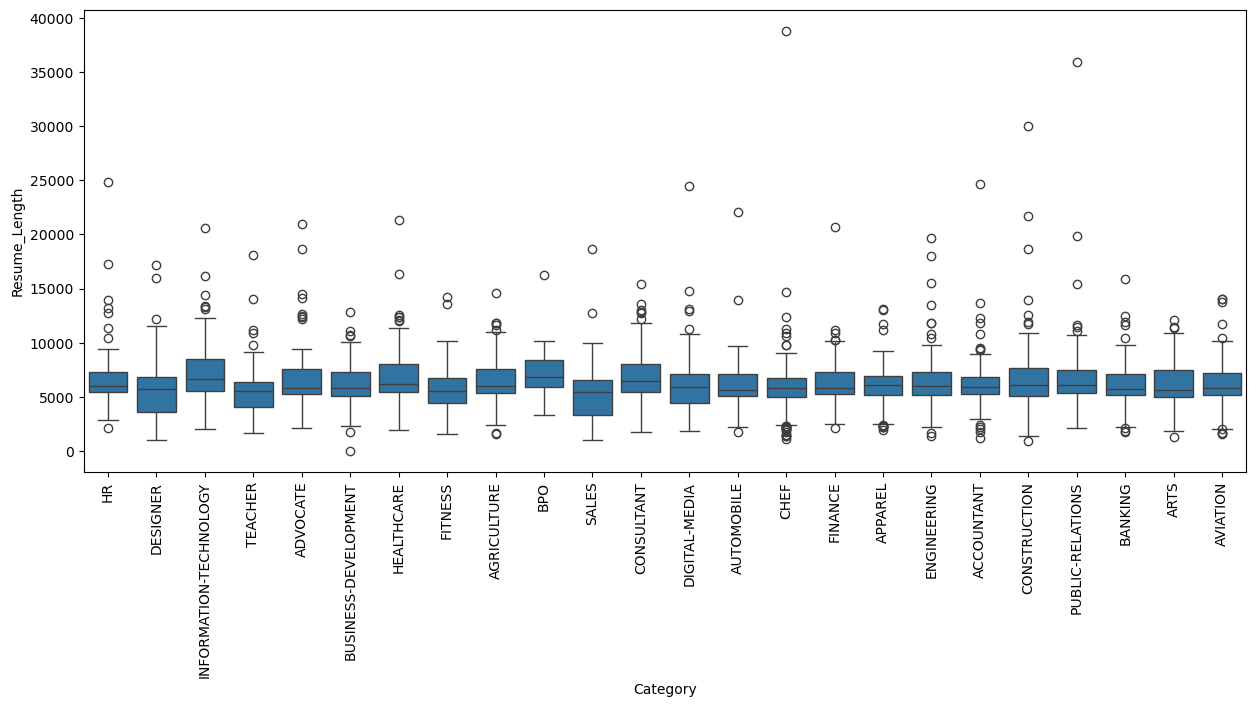

In [177]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x=data["Category"],
    y=data["Resume_Length"]
)

plt.xticks(rotation=90)
plt.show()

In [178]:
x = data.drop(["Category","Resume_Length"],axis = 1)
y = data["Category"]

In [179]:
x.head()

,Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR DIRECTOR Summary Over 2...
3,HR SPECIALIST Summary Dedica...
4,HR MANAGER Skill Highlights ...


In [180]:
y.head()

0    HR
1    HR
2    HR
3    HR
4    HR
Name: Category, dtype: object

In [181]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [182]:
vectoriser = TfidfVectorizer(stop_words="english",max_features=5000,ngram_range=(1,2),
    min_df=2)

In [183]:
vectoriser

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [184]:
x_vec = vectoriser.fit_transform(x["Resume"])

In [185]:
x_vec.shape

(2484, 5000)

In [186]:
x_train,x_test,y_train,y_test = train_test_split(x_vec,y,test_size=0.2,random_state=42,stratify=y)

In [187]:
print("Training Data Shape: ",x_train.shape)
print("Training Data Shape: ",x_train.shape)
print("Testing Data Shape: ",x_test.shape)
print("Testing Data Shape: ",y_test.shape)

Training Data Shape:  (1987, 5000)
Training Data Shape:  (1987, 5000)
Testing Data Shape:  (497, 5000)
Testing Data Shape:  (497,)


In [188]:
print("\n===== Logistic Regression Results =====\n")
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
log_pred = model.predict(x_test)

print("Accurracy: ",accuracy_score(y_test,log_pred))
print("\n")
print("Confusion Metrics: ",confusion_matrix(y_test,log_pred))
print("\n")
print("Classification Report: ",classification_report(y_test,log_pred))


===== Logistic Regression Results =====

Accurracy:  0.6599597585513078


Confusion Metrics:  [[20  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0 13  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  6  1  0  0  2  0]
 [ 0  2  6  0  1  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0  0  1  1  0]
 [ 0  3  0  4  0  0  0  0  0  4  0  0  0  1  0  1  0  0  0  1  0  1  4  0]
 [ 0  0  0  0  7  0  1  0  0  1  0  0  0  0  1  0  0  0  1  0  2  1  1  6]
 [ 0  5  0  0  0  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  1  0  0  0  0  0  3  1  0  0  1  0  0  1  0]
 [ 1  2  0  0  0  0  0 16  0  0  0  0  1  0  0  0  0  1  0  0  1  0  1  0]
 [ 0  1  0  0  0  0  0  1  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0 17  0  0  0  0  0  1  0  1  0  0  0  1  2]
 [ 0  1  0  0  0  0  0  1  0  1  0 17  0  1  0  1  0  0  0  0  0  0  0  0]
 [ 3 

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [189]:
print(data["Category"].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [195]:
print("\n===== SVM Results =====\n")
l_model = LinearSVC()
l_model.fit(x_train,y_train)
l_pred = l_model.predict(x_test)

print("Accurracy: ",accuracy_score(y_test,l_pred))

print("\n")

print("Confusion Metrics: ",confusion_matrix(y_test,l_pred))

print("\n")

print("Classification Report: ",classification_report(y_test,l_pred))


===== SVM Results =====

Accurracy:  0.7404426559356136


Confusion Metrics:  [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  1  0  2  0]
 [ 0 17  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  1  0]
 [ 0  1  8  0  1  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0  0  1  0  0]
 [ 0  2  0  7  1  0  0  0  0  1  0  0  0  1  0  1  0  1  0  1  0  1  3  0]
 [ 0  0  0  0  9  0  1  0  1  1  0  0  0  0  1  0  0  0  0  0  0  1  1  6]
 [ 0  1  0  1  0  3  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 18  0  0  1  0  0  0  0  0  3  1  0  0  1  0  0  0  0]
 [ 1  0  0  0  0  0  0 18  0  0  0  0  1  0  0  0  0  1  0  0  1  1  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  1  0  1  0  0  0  1  0]
 [ 1  0  0  0  1  0  0  0  0 20  0  0  0  0  1  0  0  0  0  1  0  0  0  0]
 [ 0  1  0  0  0  0  1  0  0  0 19  1  0  0  0  0  0  0  1  0  0  0  0  1]
 [ 0  0  0  0  0  0  0  1  0  1  0 19  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 3  1  0  0  0  0  

In [198]:
print("\n===== Navie Bayes Results =====\n")
n_model = MultinomialNB()
n_model.fit(x_train,y_train)
n_pred = n_model.predict(x_test)

print("Accurracy: ",accuracy_score(y_test,n_pred))
print("\n")
print("Confusion Metrics: ",confusion_matrix(y_test,n_pred))
print("\n")
print("Classification Report: ",classification_report(y_test,n_pred))


===== Navie Bayes Results =====

Accurracy:  0.5613682092555332


Confusion Metrics:  [[21  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  9  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  7  2  1  0  2  1]
 [ 0  2  1  0  0  0  0  0  0  0  0  3  0  0  0  1  0  1  0  0  0  3  2  0]
 [ 0  1  0  1  0  0  0  0  0  3  0  0  0  2  0  1  0  0  0  2  0  2  7  0]
 [ 0  0  0  0  3  0  1  0  0  2  0  0  0  0  1  0  0  0  1  0  2  1  0 10]
 [ 0  4  0  0  0  0  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  1  0]
 [ 0  1  0  0  0  0 15  0  0  1  0  0  0  0  0  1  2  0  0  2  1  0  1  0]
 [ 2  2  0  0  0  0  0 13  0  1  0  0  0  0  0  0  0  0  0  1  2  0  2  0]
 [ 0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  1  0  1  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  1  0  0  1  0  0]
 [ 1  1  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  1  0  0  0  2  2]
 [ 0  1  0  0  0  0  0  1  0  0  0 17  0  1  0  1  0  0  0  0  0  0  1  0]
 [ 3  2  0  0

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [200]:
# Interpretation

# Naive Bayes (56%)

# Assumes features are independent.
# Resume text contains many correlated words.
# Struggles with 24 classes.

# Logistic Regression (64%)

# Better at learning class boundaries.
# Strong baseline for text classification.

# Linear SVM (74%)

# Best model so far.
# Designed for high-dimensional sparse data like TF-IDF.
# Commonly used in resume/document classification tasks.

In [202]:
import joblib

joblib.dump(
    l_model,
    "resume_classifier.pkl"
)

joblib.dump(
    vectoriser,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

['label_encoder.pkl']